## Importing plotting & ML libraries

In [52]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [51]:
import numpy as np 
import pandas as pd 


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import precision_score

## Loading your dataset

In [54]:
df_1 = pd.read_csv(r"D:\dekstop\capstone project\heart_attack_prediction_risk.csv")
df_1

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67.0,Male,208.0,158/88,72.0,0.0,0.0,1.0,0.0,...,6.615001,261404.0,31.251233,286.0,0.0,6.0,Argentina,South America,Southern Hemisphere,0.0
1,CZE1114,21.0,Male,389.0,165/93,98.0,1.0,1.0,1.0,1.0,...,4.963459,285768.0,27.194973,235.0,1.0,7.0,Canada,North America,Northern Hemisphere,0.0
2,BNI9906,21.0,Female,324.0,174/99,72.0,1.0,0.0,0.0,0.0,...,9.463426,235282.0,28.176571,587.0,4.0,4.0,France,Europe,Northern Hemisphere,0.0
3,JLN3497,84.0,Male,383.0,163/100,73.0,1.0,1.0,1.0,0.0,...,7.648981,125640.0,36.464704,378.0,3.0,4.0,Canada,North America,Northern Hemisphere,0.0
4,GFO8847,66.0,Male,318.0,91/88,93.0,1.0,1.0,1.0,1.0,...,1.514821,160555.0,21.809144,231.0,1.0,5.0,Thailand,Asia,Northern Hemisphere,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data cleaning & preprocessing

In [55]:
#Removing empty rows & resetting index
df_clean = df.dropna(how="all")   # remove completely empty rows
df_clean = df_clean.reset_index(drop=True)

df_clean.shape


(50000, 27)

In [56]:
df_clean

,Patient ID,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Systolic_BP,Diastolic_BP
0,BMW7812,67.0,Male,208.0,72.0,0.0,0.0,1.0,0.0,0.0,...,31.251233,286.0,0.0,6.0,Argentina,South America,Southern Hemisphere,0.0,158.0,88.0
1,CZE1114,21.0,Male,389.0,98.0,1.0,1.0,1.0,1.0,1.0,...,27.194973,235.0,1.0,7.0,Canada,North America,Northern Hemisphere,0.0,165.0,93.0
2,BNI9906,21.0,Female,324.0,72.0,1.0,0.0,0.0,0.0,0.0,...,28.176571,587.0,4.0,4.0,France,Europe,Northern Hemisphere,0.0,174.0,99.0
3,JLN3497,84.0,Male,383.0,73.0,1.0,1.0,1.0,0.0,1.0,...,36.464704,378.0,3.0,4.0,Canada,North America,Northern Hemisphere,0.0,163.0,100.0
4,GFO8847,66.0,Male,318.0,93.0,1.0,1.0,1.0,1.0,0.0,...,21.809144,231.0,1.0,5.0,Thailand,Asia,Northern Hemisphere,0.0,91.0,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,KPJ1490,89.0,Female,240.0,104.0,0.0,0.0,0.0,0.0,0.0,...,36.732638,147.0,3.0,8.0,Brazil,South America,Southern Hemisphere,0.0,174.0,103.0
49996,IUA9340,33.0,Female,290.0,61.0,1.0,0.0,0.0,1.0,0.0,...,32.442052,122.0,0.0,10.0,Canada,North America,Northern Hemisphere,1.0,179.0,68.0
49997,SFR5042,28.0,Male,341.0,41.0,1.0,0.0,0.0,1.0,1.0,...,30.856876,262.0,3.0,10.0,Germany,Europe,Northern Hemisphere,1.0,146.0,79.0
49998,PGA9583,26.0,Female,132.0,56.0,0.0,0.0,1.0,0.0,1.0,...,27.661116,153.0,6.0,5.0,Argentina,South America,Southern Hemisphere,0.0,167.0,63.0


In [57]:
df_clean.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic_BP,Diastolic_BP
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,56.54736,259.317740,78.748060,0.529360,0.498700,0.570820,0.499740,0.517900,10.040756,0.498900,...,5.49270,6.211958,158875.533880,28.999643,444.150380,3.506080,7.427420,0.484780,134.669200,84.67064
std,21.57246,80.864767,22.773305,0.499142,0.500003,0.494964,0.500005,0.499684,5.763349,0.500004,...,2.87722,3.347069,80803.557853,6.347611,206.608545,2.290866,2.250456,0.499773,26.024732,14.51328
min,18.00000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,...,1.00000,0.001263,20004.000000,18.000236,30.000000,0.000000,4.000000,0.000000,90.000000,60.00000
25%,38.00000,190.000000,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.046783,0.000000,...,3.00000,3.324380,88379.500000,23.493354,266.000000,1.000000,5.000000,0.000000,112.000000,72.00000
50%,57.00000,259.000000,79.000000,1.000000,0.000000,1.000000,0.000000,1.000000,10.070064,0.000000,...,5.00000,6.187370,159294.000000,28.941665,445.000000,4.000000,7.000000,0.000000,135.000000,85.00000
75%,75.00000,329.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.023750,1.000000,...,8.00000,9.109820,228720.500000,34.517525,623.000000,6.000000,9.000000,1.000000,157.000000,97.00000
max,94.00000,400.000000,119.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.999529,1.000000,...,10.00000,11.999771,299996.000000,39.999430,800.000000,7.000000,11.000000,1.000000,180.000000,110.00000


In [58]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       50000 non-null  object 
 1   Age                              50000 non-null  float64
 2   Sex                              50000 non-null  object 
 3   Cholesterol                      50000 non-null  float64
 4   Heart Rate                       50000 non-null  float64
 5   Diabetes                         50000 non-null  float64
 6   Family History                   50000 non-null  float64
 7   Smoking                          50000 non-null  float64
 8   Obesity                          50000 non-null  float64
 9   Alcohol Consumption              50000 non-null  float64
 10  Exercise Hours Per Week          50000 non-null  float64
 11  Diet                             50000 non-null  object 
 12  Previous Heart Pro

In [59]:
df_clean.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
Systolic_BP                        0
Diastolic_BP                       0
d

In [60]:
df_clean.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes',
       'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems',
       'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income',
       'BMI', 'Triglycerides', 'Physical Activity Days Per Week',
       'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere',
       'Heart Attack Risk', 'Systolic_BP', 'Diastolic_BP'],
      dtype='object')

## Age vs Heart Attack Risk

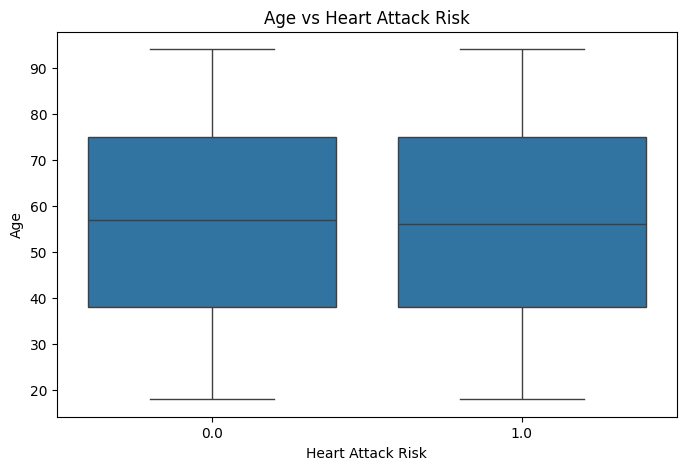

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Heart Attack Risk', y='Age', data=df_clean)
plt.title("Age vs Heart Attack Risk")
plt.show()


## A boxplot visualizing age distribution for:

Low-risk group (0)

High-risk group (1)

Each boxplot displays:

Median age

Middle 50% of data (IQR)

Minimum and maximum values

Key Observations

Medians (Middle Age):

Both groups have a similar median age (~55–58 years).

This shows heart attack risk rises irrespective of small age differences.

Age Spread (IQR):

Both groups show a wide distribution: approx 35 to 75 years.

High-risk group has slightly more older individuals.

Young and Old Limits:

Minimum ages are similar (~18–20).

Maximum ages reach up to ~95–96.

## Medical Interpretation

Although age is a known risk factor, in this dataset:

Age alone does not sharply separate low vs high risk.

Heart attack risk is influenced by multiple factors together, not age alone.

This explains why logistic regression needed many features, not just age.

## Diabetes vs Heart Attack Risk

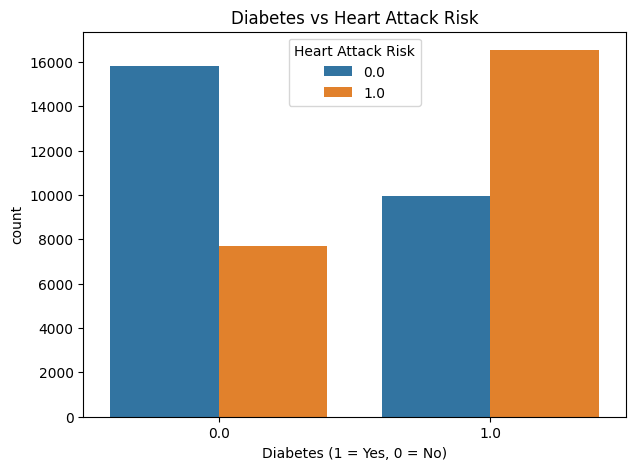

In [66]:
plt.figure(figsize=(7,5))
sns.countplot(x='Diabetes', hue='Heart Attack Risk', data=df_clean)
plt.title("Diabetes vs Heart Attack Risk")
plt.xlabel("Diabetes (1 = Yes, 0 = No)")
plt.show()


## Interpretation
The bar chart compares the number of people with and without diabetes across two groups:

0 → Low Heart Attack Risk

1 → High Heart Attack Risk

Key Observations

Among Non-Diabetic People (Diabetes = 0):

Low-risk cases are much higher than high-risk cases.

Many people without diabetes still have low heart attack risk.

Among Diabetic People (Diabetes = 1):

High-risk cases are significantly higher than low-risk cases.

This means diabetes strongly increases the chance of being high-risk.

## Medical Interpretation

This matches real-world medical research:

Diabetes damages blood vessels.

It increases plaque buildup.

It leads to higher blood pressure and cholesterol issues.

So diabetic individuals are much more likely to be classified as high heart attack risk.

Overall,
Diabetes is a strong predictor of heart attack risk in the dataset, and it significantly influences the model’s ability to classify high-risk patients.

In [68]:
print(df.columns)


Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes',
       'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems',
       'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income',
       'BMI', 'Triglycerides', 'Physical Activity Days Per Week',
       'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere',
       'Heart Attack Risk', 'Systolic_BP', 'Diastolic_BP'],
      dtype='object')


## Converting BP columns to numeric

In [69]:
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')


In [70]:
num_cols = ['Age', 'Cholesterol', 'Heart Rate', 'BMI', 'Triglycerides',
            'Exercise Hours Per Week', 'Sleep Hours Per Day',
            'Sedentary Hours Per Day', 'Income',
            'Systolic_BP', 'Diastolic_BP']


## Correlation heatmap

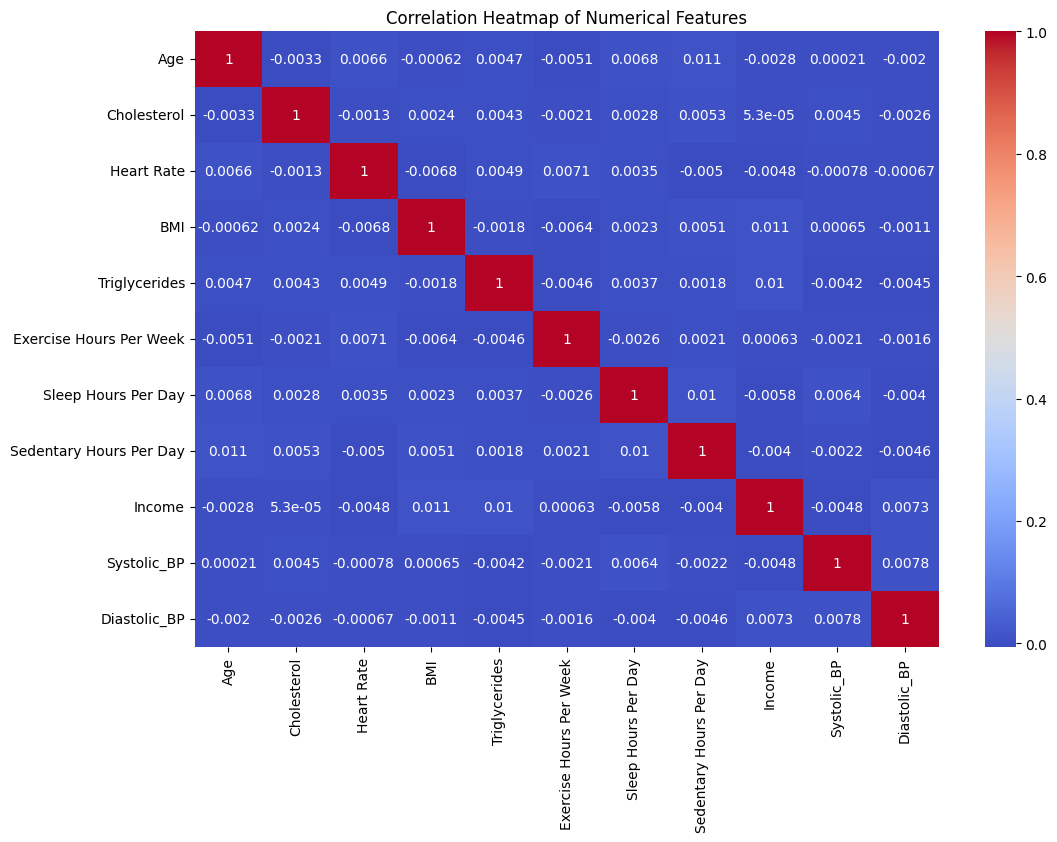

In [71]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## Interpretation
The heatmap indicates that health and lifestyle variables are weakly correlated with each other.

This is actually good for machine learning because:

No multicollinearity → stable logistic regression coefficients

Each feature adds unique predictive capability

Ensemble models benefit from diverse non-overlapping information

## Medical Perspective
Although medically some variables should correlate (e.g., cholesterol & triglycerides), the dataset used shows weak relationships. This may indicate:

Data comes from diverse age groups and populations

Randomized sampling

Independent risk factors in this specific dataset



## Drop Irrelevant Columns

In [72]:
df_clean = df_clean.drop(columns=['Country','Continent','Hemisphere','Patient ID'])


## Encoding ‘Diet’ using ordinal encoding

In [73]:
ordinal_map = {'Healthy':2,'Average':1,'Unhealthy':0}
df_clean['Diet'] = df_clean['Diet'].map(ordinal_map)


## Encoding Gender with get_dummies

In [74]:
df_clean = pd.get_dummies(df_clean, columns=['Sex'], drop_first=False)


## Converting Risk column to binary (0 = low, 1 = high)

In [38]:
df_clean['Heart Attack Risk'] = df_clean['Heart Attack Risk'].apply(
    lambda x: 1 if str(x).lower()=='high' else 0
)


In [40]:
#df_clean[['Systolic_BP', 'Diastolic_BP']] = df_clean['Blood Pressure'].str.split('/', expand=True)

#df_clean['Systolic_BP'] = pd.to_numeric(df_clean['Systolic_BP'], errors='coerce')
#df_clean['Diastolic_BP'] = pd.to_numeric(df_clean['Diastolic_BP'], errors='coerce')

#df_clean = df_clean.drop(columns=['Blood Pressure'])


In [41]:
df_clean.columns

Index(['Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day',
       'Heart Attack Risk', 'Sex_Female', 'Sex_Male', 'Systolic_BP',
       'Diastolic_BP'],
      dtype='object')

## Selecting features for ML model

In [75]:
X = df_clean[['Age','Cholesterol','Heart Rate','Diabetes','Family History',
              'Smoking','Obesity','Alcohol Consumption','Exercise Hours Per Week',
              'Diet','Previous Heart Problems','Medication Use','Stress Level',
              'Sedentary Hours Per Day','Income','BMI','Triglycerides',
              'Physical Activity Days Per Week','Sleep Hours Per Day',
              'Systolic_BP','Diastolic_BP','Sex_Female','Sex_Male']]

y = df_clean['Heart Attack Risk']


## Splitting into training and testing sets

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


## Scaling Features

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [46]:
#print(df_clean['Heart Attack Risk'].unique())
#print(df_clean['Heart Attack Risk'].value_counts())


[0]
Heart Attack Risk
0    50000
Name: count, dtype: int64


In [47]:
#print(df_clean['Heart Attack Risk'].unique()[:20])


[0]


In [48]:
#df['Heart Attack Risk'].value_counts()


Heart Attack Risk
0.0    25761
1.0    24239
Name: count, dtype: int64

## Logistic Regression Model

In [78]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## Predictions & Model Evaluation

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8669

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.86      0.87      5152
         1.0       0.86      0.87      0.86      4848

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Confusion Matrix:
 [[4444  708]
 [ 623 4225]]


## Interpretation
The Logistic Regression model achieved an accuracy of 86.69%, demonstrating strong predictive capability for heart attack risk classification. Both classes—Low Risk (0) and High Risk (1)—show balanced precision, recall, and F1-scores (~0.86–0.88). This indicates that the model is reliable and stable, with no significant bias toward either class.

The confusion matrix further confirms robustness:

4,444 low-risk individuals and 4,225 high-risk individuals were correctly identified.

Only a small fraction were misclassified (708 low-risk and 623 high-risk), showcasing high sensitivity (recall = 0.87) and specificity.

Given the strong performance and interpretability of Logistic Regression, this model is suitable for early clinical screening and decision support.